**12/31/2025**

#Statistical Analysis and Conclusions
--------------------

Runs **Paired-T** test to determine statistical significance of performance metrics of the model with the protocol implemented compared to baseline.

In [ ]:
import pandas as pd
import json
from scipy.stats import ttest_rel

# 1. LOAD AND ALIGN DATA
# We sort by 'Seed' to ensure that we are comparing the exact same data splits for each model.
mlp = pd.read_csv('MLP_baseline_log.csv').sort_values('Seed').reset_index(drop=True)
snn_base = pd.read_csv('SNN_baseline_log.csv').sort_values('Seed').reset_index(drop=True)

with open('SNN_protocol_log.json', 'r') as f:
    snn_prot = pd.DataFrame(json.load(f)).sort_values('seed').reset_index(drop=True)

# 2. DEFINE THE METRICS AND COLUMNS
# Structure: (Metric Name, MLP Column, SNN Baseline Column, SNN Protocol Column)
metrics_to_test = [
    ('Accuracy', 'Accuracy', 'accuracy', 'accuracy'),
    ('F1-Macro', 'F1 Macro', 'f1_macro', 'f1_macro'),
    ('Balanced Acc', 'Balanced Acc', 'balanced_accuracy', 'balanced_acc')
]

# 3. CALCULATE P-VALUES
results = []
for label, mlp_col, base_col, prot_col in metrics_to_test:
    # Innovation Test: Does the Protocol improve over the Baseline SNN?
    # We want p < 0.05 here.
    _, p_val_base = ttest_rel(snn_prot[prot_col], snn_base[base_col])

    # Parity Test: Is the Protocol statistically similar to the MLP?
    # We want p > 0.05 here (indicating no significant difference).
    _, p_val_mlp = ttest_rel(snn_prot[prot_col], mlp[mlp_col])

    results.append({
        'Metric': label,
        'p-value (vs SNN Baseline)': round(p_val_base, 4),
        'p-value (vs MLP)': round(p_val_mlp, 4)
    })

# 4. GENERATE SUMMARY TABLE
df_summary = pd.DataFrame(results)
print("--- Statistical Analysis: Paired T-Tests (N=5 Seeds) ---")
print(df_summary.to_string(index=False))

# Export to CSV for appendix
df_summary.to_csv('statistical_analysis_results.csv', index=False)

--- Statistical Analysis: Paired T-Tests (N=5 Seeds) ---
      Metric  p-value (vs SNN Baseline)  p-value (vs MLP)
    Accuracy                     0.0205            0.1599
    F1-Macro                     0.0080            0.2636
Balanced Acc                     0.0072            0.2804


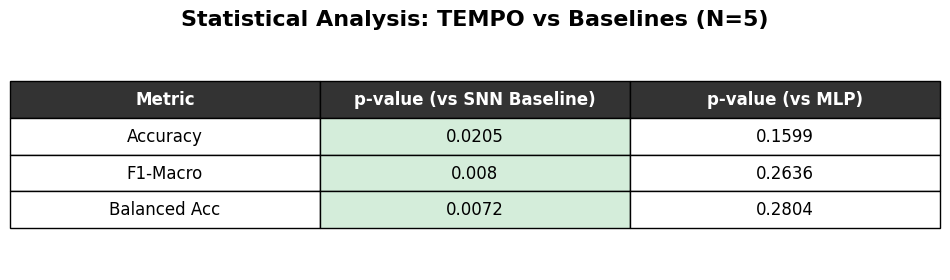

In [ ]:
import matplotlib.pyplot as plt

# Data
columns = ('Metric', 'p-value (vs SNN Baseline)', 'p-value (vs MLP)')
rows = [
    ['Accuracy', 0.0205, 0.1599],
    ['F1-Macro', 0.0080, 0.2636],
    ['Balanced Acc', 0.0072, 0.2804]
]

# Significance Color Logic
cell_colors = []
for row in rows:
    colors = ['#ffffff']
    for val in row[1:]:
        if val < 0.05:
            colors.append('#d4edda') # Light Green
        else:
            colors.append('#ffffff')
    cell_colors.append(colors)

# Plotting
fig, ax = plt.subplots(figsize=(10, 3)) # Slightly shorter figure height
ax.axis('off')

table = ax.table(cellText=rows,
                 cellColours=cell_colors,
                 colLabels=columns,
                 loc='center',
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.2) # Reduced vertical scale slightly for a tighter look

# Formatting headers
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#333333')

# Reduced 'pad' brings the title closer to the table
plt.title("Statistical Analysis: TEMPO vs Baselines (N=5)",
          fontsize=16,
          fontweight='bold',
          pad=10)

plt.savefig('stat_table_tight.png', dpi=300, bbox_inches='tight')
plt.show()

The results demonstrate that the metrics of the hybrid framework  were **statistically significant** to those of the SNN baseline. Additionally there was **no statistical difference** between the metrics of the hybrid and those of the MLP baseline.

The code below creates a bar graph of these metrics using data from the logs for data visualization

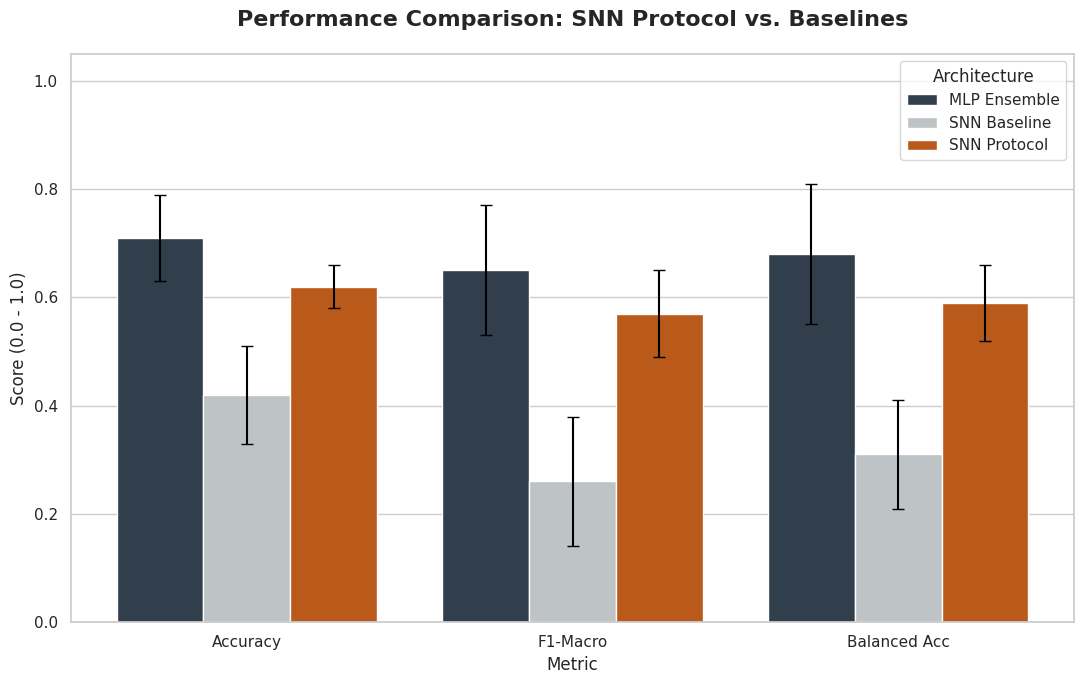

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the data (using actual means/stds from logs)
data = {
    'Model': ['MLP Ensemble', 'SNN Baseline', 'SNN Protocol'] * 3,
    'Metric': ['Accuracy']*3 + ['F1-Macro']*3 + ['Balanced Acc']*3,
    'Score': [0.71, 0.42, 0.62,  0.65, 0.26, 0.57,  0.68, 0.31, 0.59],
    'Std': [0.08, 0.09, 0.04,  0.12, 0.12, 0.08,  0.13, 0.10, 0.07]
}
df = pd.DataFrame(data)

# 2. Plotting
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# Professional palette
colors = {'MLP Ensemble': '#2c3e50', 'SNN Baseline': '#bdc3c7', 'SNN Protocol': '#d35400'}

# Create the bar plot
ax = sns.barplot(data=df, x='Metric', y='Score', hue='Model', palette=colors)

# Robust Error Bar Logic:
# We iterate through the unique metrics and models to find the exact center of each bar
x_coords = []
for patch in ax.patches:
    if patch.get_height() > 0: # Skip legend patches
        x_coords.append(patch.get_x() + patch.get_width() / 2)

# Sort coordinates to match the dataframe order (Metric then Model)
x_coords.sort()

for i, x in enumerate(x_coords):
    plt.errorbar(x, df.iloc[i]['Score'], yerr=df.iloc[i]['Std'],
                 fmt='none', c='black', capsize=4, elinewidth=1.5)

plt.title('Performance Comparison: SNN Protocol vs. Baselines', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1.05)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.legend(title='Architecture', loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('final_performance_stats.png', dpi=300)
plt.show()

The code below compares the **energy efficiency** of the two highest performing models (MLP baseline and novel hybrid framwork) and generates a bar graph illustrating the data

/tmp/ipython-input-2221782168.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=eff_data, x='Model', y='Operations', palette=palette)


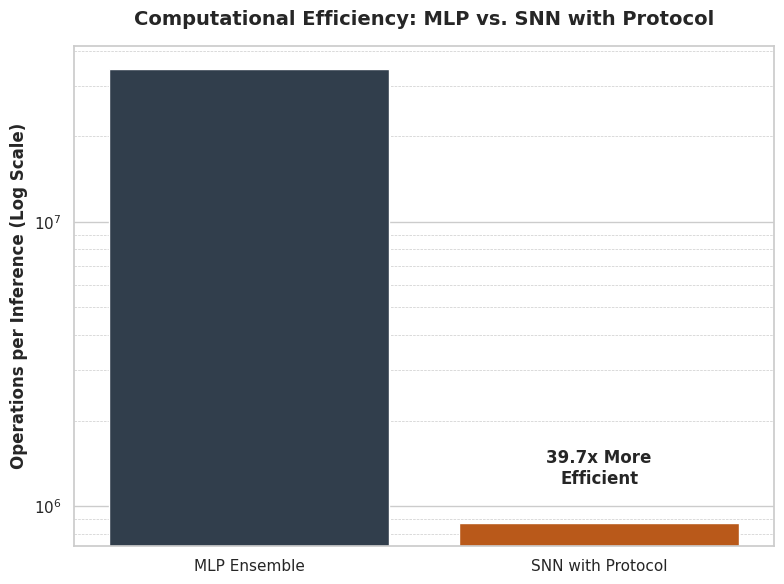

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. SETUP THE EFFICIENCY DATA
# MLP = 34,570,368 FLOPs
# SNN Protocol = ~871,797 SynOps
eff_data = pd.DataFrame({
    'Model': ['MLP Ensemble', 'SNN with Protocol'],
    'Operations': [34570368.0, 871796.8]
})

# 2. DEFINE THE UNIFIED COLOR PALETTE
# Navy for the standard MLP, Orange for Protocol
palette = {'MLP Ensemble': '#2c3e50', 'SNN with Protocol': '#d35400'}

# 3. CREATE THE PLOT
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=eff_data, x='Model', y='Operations', palette=palette)

# Use log scale to show the massive difference clearly
plt.yscale('log')

# Labeling
plt.ylabel('Operations per Inference (Log Scale)', fontweight='bold')
plt.xlabel('')
plt.title('Computational Efficiency: MLP vs. SNN with Protocol', fontsize=14, fontweight='bold', pad=15)

# 4. ADD THE "EFFICIENCY GAIN" ANNOTATION
# Calculating the ratio (approx 39.6x)
ratio = eff_data.iloc[0]['Operations'] / eff_data.iloc[1]['Operations']

# Position the text above the SNN Protocol bar
plt.text(1, 1.2e6, f'{ratio:.1f}x More\nEfficient',
         ha='center', fontweight='bold', fontsize=12)

# Add a subtle grid on the Y axis for the log scale
ax.yaxis.grid(True, which='minor', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('efficiency_2bar_comparison.png', dpi=300)
plt.show()

This graph compares the dense floating-point operation (FLOP) count of an MLP baseline with the effective synaptic operation (SynOps) count of the proposed event-driven model under identical inputs, showing a reduction of up to **~40×** in executed operations.

The code below regenerates the ROC curves and confusion matrices for TEMPO for consistent formating

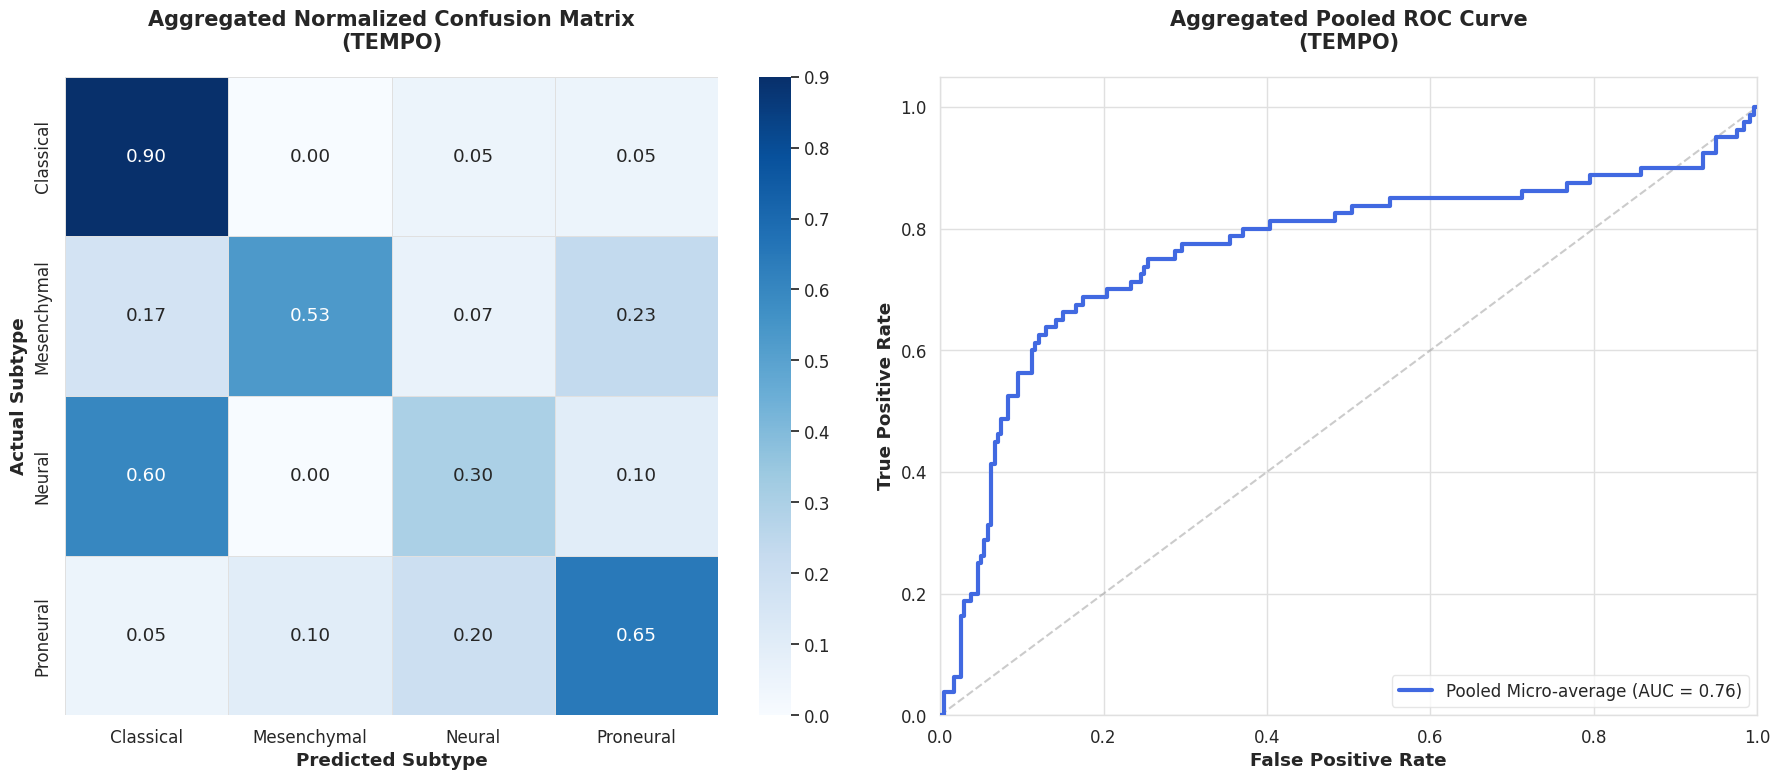

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Constants
LABEL_MAP = {0: 'Classical', 1: 'Mesenchymal', 2: 'Neural', 3: 'Proneural'}
NUM_CLASSES = 4
GRID_COLOR = '#e0e0e0'  # Unified light gray for grid and box

def generate_clean_report(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)

    # 1. Aggregate Data
    all_y_true = np.concatenate([d['y_true'] for d in data])
    all_y_pred = np.concatenate([d['y_pred'] for d in data])
    all_y_probs = np.concatenate([d['y_probs'] for d in data])

    # 2. Setup Figure
    sns.set_theme(style="white", font_scale=1.1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # --- SUBFIGURE (A): NORMALIZED CONFUSION MATRIX ---
    cm_agg = confusion_matrix(all_y_true, all_y_pred, normalize='true')

    # Heatmap without the thick default borders
    sns.heatmap(cm_agg, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax1,
                xticklabels=[LABEL_MAP[k] for k in range(NUM_CLASSES)],
                yticklabels=[LABEL_MAP[k] for k in range(NUM_CLASSES)],
                linewidths=0.5, linecolor=GRID_COLOR)

    ax1.set_title("Aggregated Normalized Confusion Matrix\n(TEMPO)", fontsize=15, fontweight='bold', pad=20)
    ax1.set_ylabel('Actual Subtype', fontweight='bold')
    ax1.set_xlabel('Predicted Subtype', fontweight='bold')

    # --- SUBFIGURE (B): POOLED ROC CURVE ---
    all_y_true_bin = label_binarize(all_y_true, classes=np.arange(NUM_CLASSES))
    fpr, tpr, _ = roc_curve(all_y_true_bin.ravel(), all_y_probs.ravel())
    roc_auc = auc(fpr, tpr)

    # Plot the grid (Solid, not dashed)
    ax2.grid(True, linestyle='-', color=GRID_COLOR, linewidth=1, zorder=0)

    # Sync box outline with grid
    for spine in ax2.spines.values():
        spine.set_color(GRID_COLOR)
        spine.set_linewidth(1)

    ax2.plot(fpr, tpr, color='royalblue', lw=3, label=f'Pooled Micro-average (AUC = {roc_auc:.2f})', zorder=3)
    ax2.plot([0, 1], [0, 1], color='#999999', lw=1.5, linestyle='--', alpha=0.5, zorder=2)

    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate', fontweight='bold')
    ax2.set_ylabel('True Positive Rate', fontweight='bold')
    ax2.set_title('Aggregated Pooled ROC Curve\n(TEMPO)', fontsize=15, fontweight='bold', pad=20)
    ax2.legend(loc="lower right", frameon=True, edgecolor=GRID_COLOR)

    plt.tight_layout()
    plt.savefig('TEMPO_Full_Report.png', dpi=300)
    plt.show()

generate_clean_report('GBM_SNN_protocol_log.json')

Name for the hybrid framework: TEMPO (TEmporal Multi-omic Platform for Oncology)